# Project 9 - Machine Learning in Business

## Introduction:

As hydrogeologists working for the `OilyGiant` mining company, our task is to find the best place for a new well.

Steps to choose the location:

- Collecting the oil well parameters in the selected region: oil quality and volume of reserves;
- Building a model for predicting the volume of reserves in the new wells;
- Picking the oil wells with the highest estimated values;
- Picking the region with the highest total profit for the selected oil wells.

Data on oil samples from three regions have been provided. Parameters of each oil well in the region are already known. 

With that said, let's build a model that will help to pick the region with the highest profit margin. Also, let's analyze potential profit and risks using the Bootstrapping technique.

## Data description:

These are the files in which geolgical exploration data for the three regions are stored:

- `geo_data_0.csv`
- `geo_data_1.csv`
- `geo_data_2.csv`


Features:

- `id` — unique oil well identifier
- `f0`, `f1`, `f2` — three features of points (their specific meaning is unimportant, but the features themselves are significant)
- `product` — volume of reserves in the oil well (thousand barrels).

Conditions:

- Only linear regression is suitable for model training (the rest are not sufficiently predictable).
- When exploring the region, a study of 500 points is carried with picking the best 200 points for the profit calculation.
- The budget for development of 200 oil wells is 100 USD million.
- One barrel of raw materials brings 4.5 USD of revenue The revenue from one unit of product is 4,500 dollars (volume of reserves is in thousand barrels).
- After the risk evaluation, keep only the regions with the risk of losses lower than 2.5%. From the ones that fit the criteria, the region with the highest average profit should be selected.
- The data is synthetic: contract details and well characteristics are not disclosed.

## Instructions:

### Step 1 - *Download and prepare the data as well as explain the procedure:*

#### Downloading the data:

In [179]:
# Task 1: Importing the libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import mean_squared_error
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import StandardScaler

In [180]:
# Task 2: Importing the data files

df0 = pd.read_csv('/datasets/geo_data_0.csv')
df1 = pd.read_csv('/datasets/geo_data_1.csv')
df2 = pd.read_csv('/datasets/geo_data_2.csv')

#### Preparing the `df0` data while explaining the procedure:

In [181]:
# Task 1: Using the `.info()` method to get a summary of the data type in df0

print(df0.info)

<bound method DataFrame.info of           id        f0        f1        f2     product
0      txEyH  0.705745 -0.497823  1.221170  105.280062
1      2acmU  1.334711 -0.340164  4.365080   73.037750
2      409Wp  1.022732  0.151990  1.419926   85.265647
3      iJLyR -0.032172  0.139033  2.978566  168.620776
4      Xdl7t  1.988431  0.155413  4.751769  154.036647
...      ...       ...       ...       ...         ...
99995  DLsed  0.971957  0.370953  6.075346  110.744026
99996  QKivN  1.392429 -0.382606  1.273912  122.346843
99997  3rnvd  1.029585  0.018787 -1.348308   64.375443
99998  7kl59  0.998163 -0.528582  1.583869   74.040764
99999  1CWhH  1.764754 -0.266417  5.722849  149.633246

[100000 rows x 5 columns]>


In [182]:
# Task 2: Using the `.head()` method to get an overview of the first 10 entries in df0

print(df0.head())

      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647


In [183]:
# Task 3: Using the `.tail()` method to get an overview of the last 10 entries in df0

print(df0.tail())

          id        f0        f1        f2     product
99995  DLsed  0.971957  0.370953  6.075346  110.744026
99996  QKivN  1.392429 -0.382606  1.273912  122.346843
99997  3rnvd  1.029585  0.018787 -1.348308   64.375443
99998  7kl59  0.998163 -0.528582  1.583869   74.040764
99999  1CWhH  1.764754 -0.266417  5.722849  149.633246


In [184]:
# Task 4: Using the `.describe()` method to get basic statistics like `mean` and `count` for df0

print(df0.describe())

                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331       1.343769      16.003790     185.364347


In [185]:
# Task 5: Checking for missing values, including NaN and infinite ones, in df0

print(df0.isnull().sum())

id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


In [186]:
# Task 6: Checking for duplicates in df0

print(df0.duplicated().sum())

0


In [187]:
# Task 7: Visualizing df0

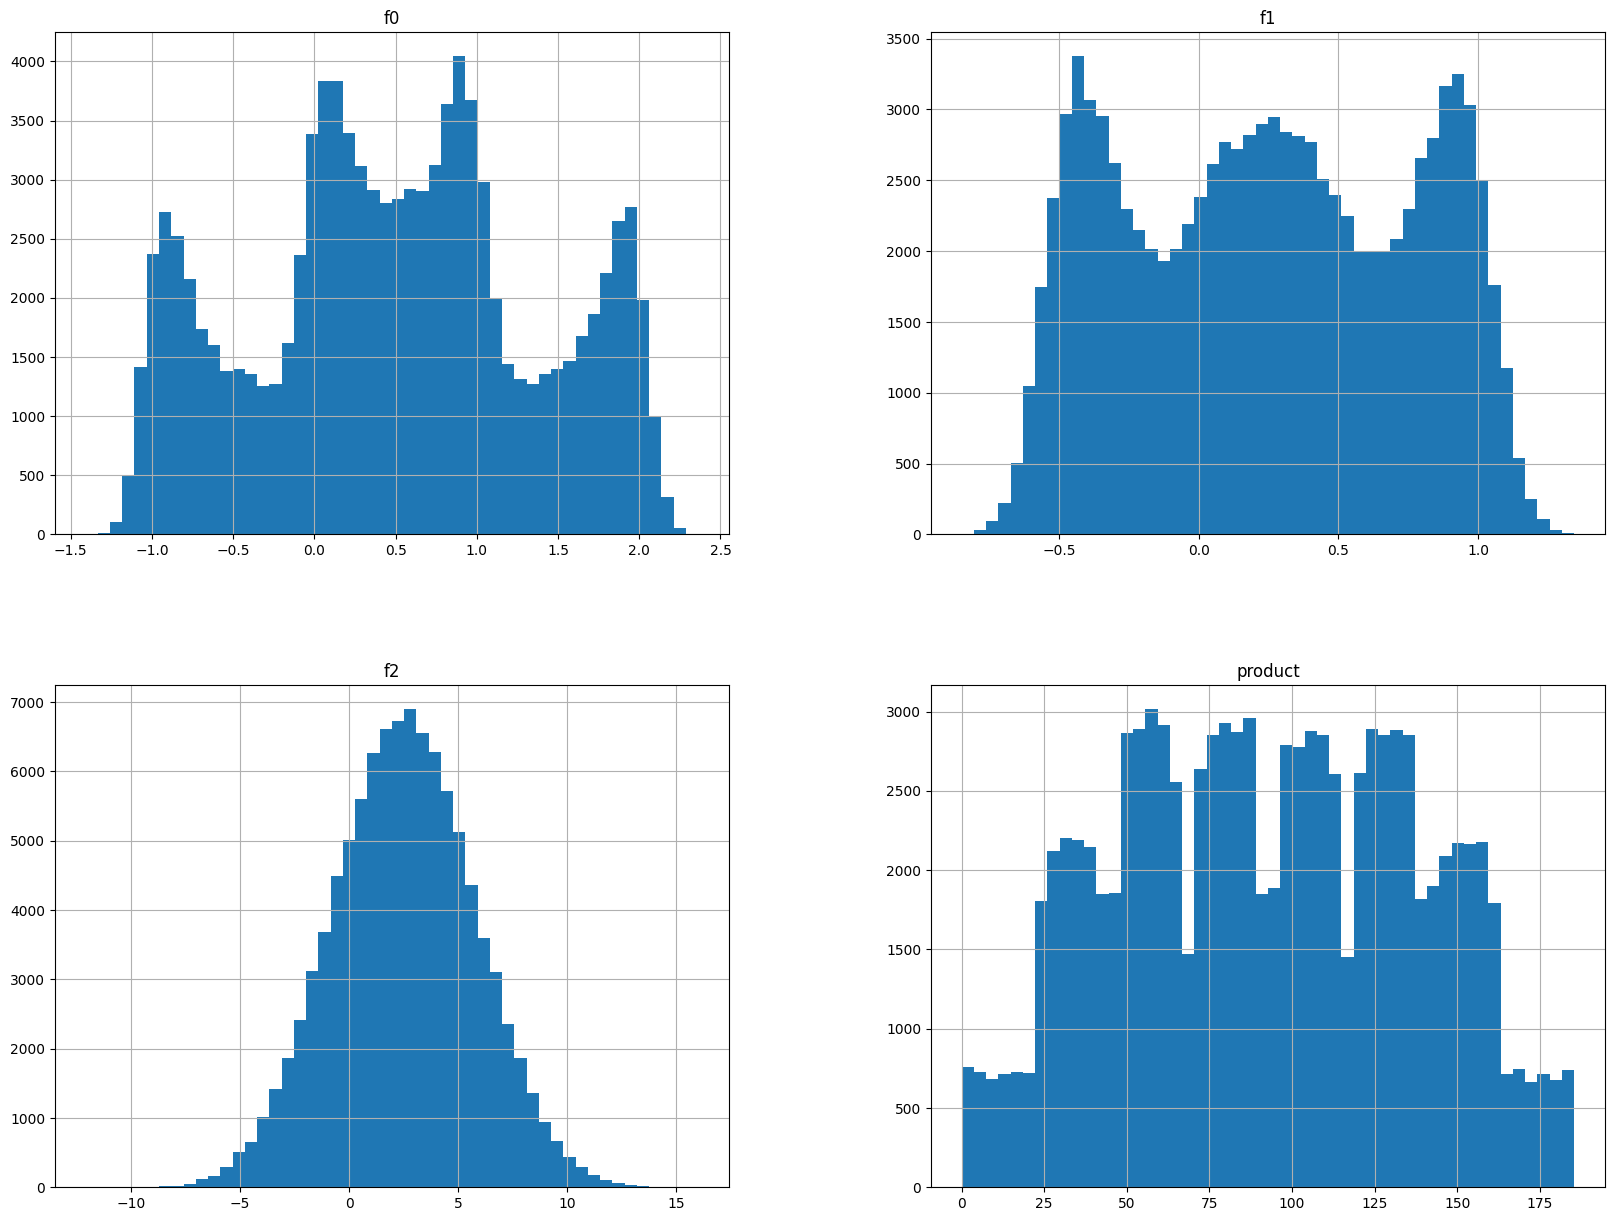

In [188]:
## With a histogram, to understand the distribution of each feature (f0, f1, f2) and the product:

df0.hist(bins=50, figsize=(20, 15))
plt.show()

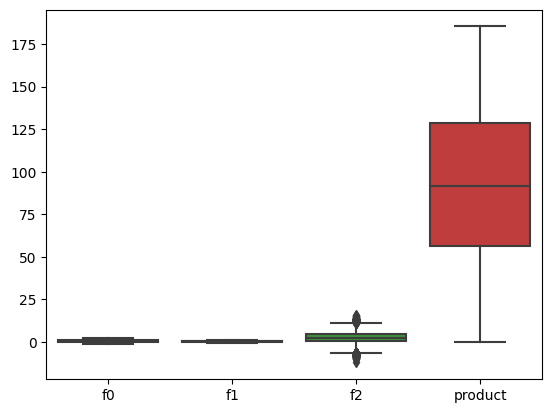

In [189]:
## With a box plot, to identify outliers and understand the spread of the data:

sns.boxplot(data=df0[['f0', 'f1', 'f2', 'product']])
plt.show()   

In [ ]:
## With a pair plot, to display relationships and distributions for all pairs of features:

sns.pairplot(df0)
plt.show()   

In [ ]:
## With a correlation matrix, to display correlations between features using a heatmap:

corr_matrix = df0.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()   

In [ ]:
## With a scatter plot, to examine the relationships between two specific features:

plt.scatter(df0['f0'], df0['product'])
plt.xlabel('Feature f0')
plt.ylabel('Product')
plt.show()   

#### Preparing the `df1` data while preparing the procedure:

In [ ]:
# Task 1: Using the `.info()` method to get a summary of the data type in df0

print(df1.info)

In [ ]:
# Task 2: Using the `.head()` method to get an overview of the first 10 entries in df1

print(df1.head())

In [ ]:
# Task 3: Using the `.tail()` method to get an overview of the last 10 entries in df1

print(df1.tail())

In [ ]:
# Task 4: Using the `.describe()` method to get basic statistics like `mean` and `count` for df1

print(df1.describe())

In [ ]:
# Task 5: Checking for missing values, including NaN and infinite ones, in df1

print(df1.isnull().sum())

In [ ]:
# Task 6: Checking for duplicates in df1

print(df1.duplicated().sum())

In [ ]:
# Task 7: Visualizing df1

In [ ]:
## With a histogram, to understand the distribution of each feature (f0, f1, f2) and the product:

df1.hist(bins=50, figsize=(20, 15))
plt.show()

In [ ]:
## With a box plot, to identify outliers and understand the spread of the data:

sns.boxplot(data=df1[['f0', 'f1', 'f2', 'product']])
plt.show()

In [ ]:
## With a pair plot, to display relationships and distributions for all pairs of features:

sns.pairplot(df1)
plt.show()   

In [ ]:
## With a correlation matrix, to display correlations between features using a heatmap:

corr_matrix = df1.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()   

In [ ]:
## With a scatter plot, to examine the relationships between two specific features:

plt.scatter(df1['f0'], df1['product'])
plt.xlabel('Feature f0')
plt.ylabel('Product')
plt.show()  

#### Preparing the `df2` data while preparing the procedure:

In [ ]:
# Task 1: Using the `.info()` method to get a summary of the data type in df0

print(df2.info)

In [ ]:
# Task 2: Using the `.head()` method to get an overview of the first 10 entries in df2

print(df2.head())

In [ ]:
# Task 3: Using the `.tail()` method to get an overview of the last 10 entries in df2

print(df2.tail())

In [ ]:
# Task 4: Using the `.describe()` method to get basic statistics like `mean` and `count` for df2

print(df2.describe())

In [ ]:
# Task 5: Checking for missing values, including NaN and infinite ones, in df2

print(df2.isnull().sum())

In [ ]:
# Task 6: Checking for duplicates in df2

print(df2.duplicated().sum())

In [ ]:
# Task 7: Visualizing df2

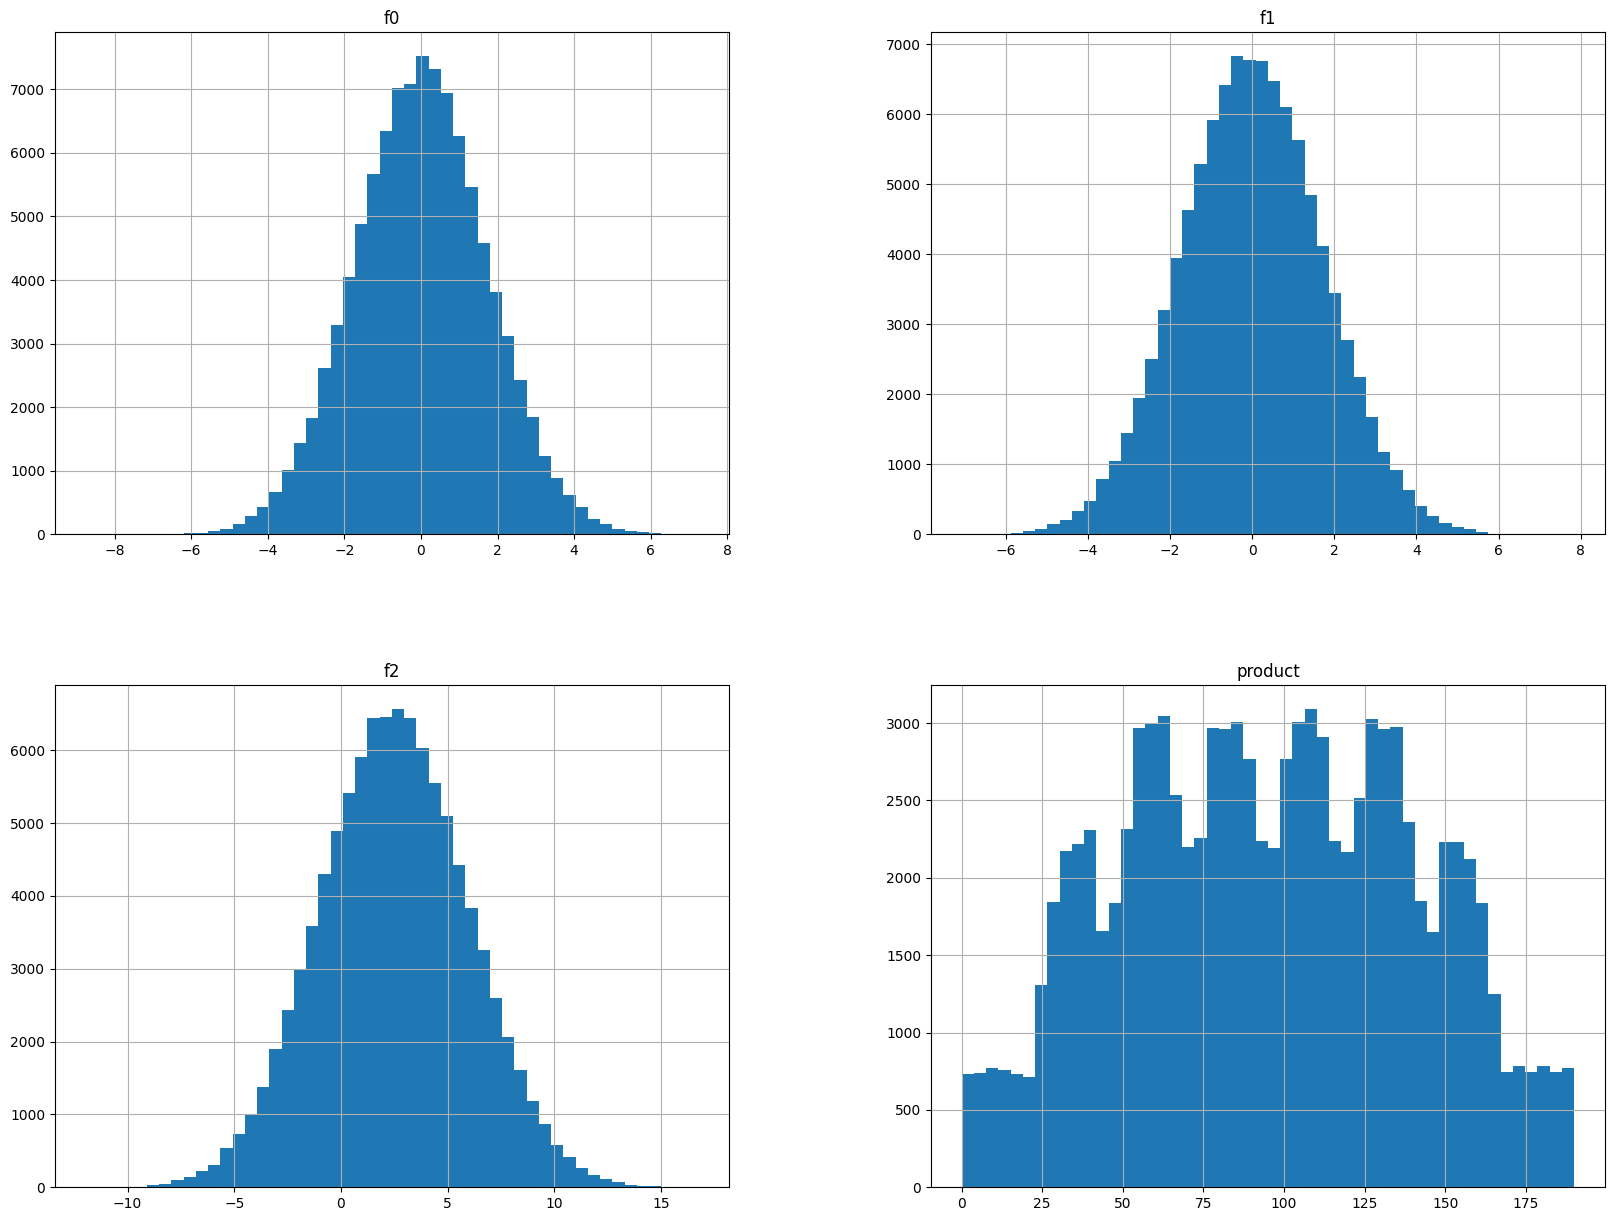

In [212]:
## With a histogram, to understand the distribution of each feature (f0, f1, f2) and the product:

df2.hist(bins=50, figsize=(20, 15))
plt.show()

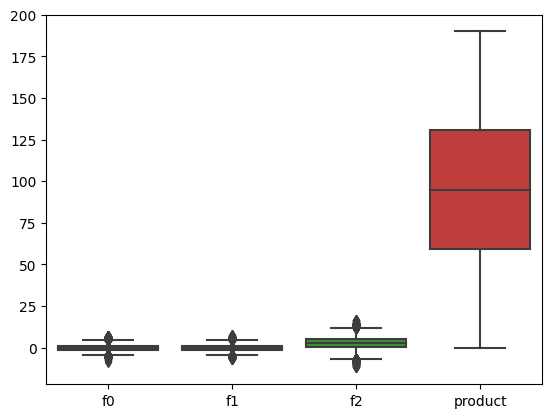

In [213]:
## With a box plot, to identify outliers and understand the spread of the data:

sns.boxplot(data=df2[['f0', 'f1', 'f2', 'product']])
plt.show() 

In [ ]:
## With a pair plot, to display relationships and distributions for all pairs of features:

sns.pairplot(df2)
plt.show()

In [ ]:
## With a correlation matrix, to display correlations between features using a heatmap:

corr_matrix = df2.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
## With a scatter plot, to examine the relationships between two specific features:

plt.scatter(df2['f0'], df2['product'])
plt.xlabel('Feature f0')
plt.ylabel('Product')
plt.show()   

### Summary of Step 1:

To comply with Step 1, we performed these tasks:

- Importing the libraries to perform tasks for each step of the project with.
- Importing the project's data files — df0, df1, and df2.
- Performing a host of subtasks in terms of visualizing the data files through various graph types.

### Step 2 - *Train and test the model for each region:*

#### Splitting the data into a training set and validation set at a ratio of 75:25:

In [ ]:
# Preparing features and target for df0

features_0 = df0.drop(['product', 'id'], axis=1)
target_0 = df0['product']

print(features_0)
print(target_0)

In [ ]:
# Splitting the data for df0

X_train_0, X_valid_0, y_train_0, y_valid_0 = train_test_split(
    features_0, target_0, test_size=0.25, random_state=42
)

In [ ]:
# Preparing features and target for df1

features_1 = df1.drop(['product', 'id'], axis=1)
target_1 = df1['product']

print(features_1)
print(target_1)

In [ ]:
# Splitting the data for df1

X_train_1, X_valid_1, y_train_1, y_valid_1 = train_test_split(
    features_1, target_1, test_size=0.25, random_state=42
)

In [ ]:
# Preparing features and target for df2

features_2 = df2.drop(['product', 'id'], axis=1)
target_2 = df2['product']

print(features_2)
print(target_2)

In [ ]:
# Splitting the data for df2

X_train_2, X_valid_2, y_train_2, y_valid_2 = train_test_split(
    features_2, target_2, test_size=0.25, random_state=42
)

#### Training the model and make predictions for the validation set:

In [ ]:
# Training the model of df0

model_0 = LinearRegression()
model_0.fit(X_train_0, y_train_0)

In [ ]:
# Making predictions for the validation set of df0

predictions_0 = model_0.predict(X_valid_0)

print(predictions_0)

In [ ]:
# Training the model of df1

model_1 = LinearRegression()
model_1.fit(X_train_1, y_train_1)

In [ ]:
# Making predictions for the validation set of df1

predictions_1 = model_1.predict(X_valid_1)

print(predictions_1)

In [ ]:
# Training the model of df2

model_2 = LinearRegression()
model_2.fit(X_train_2, y_train_2)

In [ ]:
# Making predictions for the validation set of df2

predictions_2 = model_2.predict(X_valid_2)

print(predictions_2)

#### Saving the predictions and correct answers for the validation set:

In [ ]:
# Saving predictions for df0

results_0 = pd.DataFrame({'predictions': predictions_0, 'actual': y_valid_0})

results_0.to_csv('results_region0.csv', index=False)

print(results_0)

In [ ]:
# Saving predictions for df1

results_1 = pd.DataFrame({'predictions': predictions_1, 'actual': y_valid_1})

results_1.to_csv('results_region1.csv', index=False)

print(results_1)

In [ ]:
# Saving predictions for df2

results_2 = pd.DataFrame({'predictions': predictions_2, 'actual': y_valid_2})

results_2.to_csv('results_region2.csv', index=False)

print(results_2)

#### Printing the average volume of predicted reserves and model RMSE:

In [ ]:
# Evaluating df0 using RMSE and mean predicted volume 

rmse_0 = np.sqrt(mean_squared_error(y_valid_0, predictions_0))
mean_predicted_vol_0 = predictions_0.mean()

print(f"Region 0 - RMSE: {rmse_0}")
print(f"Region 0 - Mean predicted volume: {mean_predicted_vol_0}")

In [ ]:
# Evaluating df1 using RMSE and mean predicted volume 

rmse_1 = np.sqrt(mean_squared_error(y_valid_1, predictions_1))
mean_predicted_vol_1 = predictions_0.mean()

print(f"Region 1 - RMSE: {rmse_1}")
print(f"Region 1 - Mean predicted volume: {mean_predicted_vol_1}")

In [ ]:
# Evualing df2 using RMSE and mean predicted volume 

rmse_2 = np.sqrt(mean_squared_error(y_valid_2, predictions_2))
mean_predicted_vol_2 = predictions_2.mean()

print(f"Region 2 - RMSE: {rmse_2}")
print(f"Region 2 - Mean predicted volume: {mean_predicted_vol_2}")

#### Analyzing the results:

In [ ]:
# Creating a histogram of the predicted versus actual values to see distribution differences in df0

plt.figure(figsize=(12, 6))
plt.hist(results_0['actual'], bins=50, alpha=0.5, label='Actual')
plt.hist(results_0['predictions'], bins=50, alpha=0.5, label='Predicted')
plt.xlabel('Volume of Reserves')
plt.ylabel('Frequency')
plt.title('Distribution of Actual vs Predicted for Region 0')
plt.legend()
plt.show()

In [ ]:
# Plotting boxplots to identify outliers, as well as understand the spread of predictions, in df0

plt.figure(figsize=(8, 6))
sns.boxplot(data=results_0[['actual', 'predictions']])
plt.title('Boxplot of Actual vs Predicted for Region 0')
plt.show()

In [ ]:
# Calculating and printing the correction matrix in df0

correlation_matrix = results_0.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Region 0')
plt.show()

In [ ]:
# Printing RMSE and MAE in df0

from sklearn.metrics import mean_absolute_error

rmse_0 = np.sqrt(mean_squared_error(results_0['actual'], results_0['predictions']))
mae_0 = mean_absolute_error(results_0['actual'], results_0['predictions'])

print(f"Region 0 - RMSE: {rmse_0}")
print(f"Region 0 - MAE: {mae_0}")

In [ ]:
# Creating a histogram of the predicted versus actual values to see distribution differences in df1

plt.figure(figsize=(12, 6))
plt.hist(results_1['actual'], bins=50, alpha=0.5, label='Actual')
plt.hist(results_1['predictions'], bins=50, alpha=0.5, label='Predicted')
plt.xlabel('Volume of Reserves')
plt.ylabel('Frequency')
plt.title('Distribution of Actual vs Predicted for Region 1')
plt.legend()
plt.show()

In [ ]:
# Plotting boxplots to identify outliers, as well as understand the spread of predictions, in df1

plt.figure(figsize=(8, 6))
sns.boxplot(data=results_1[['actual', 'predictions']])
plt.title('Boxplot of Actual vs Predicted for Region 1')
plt.show()

In [ ]:
# Calculating and printing the correction matrix in df1

correlation_matrix = results_1.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Region 1')
plt.show()

In [ ]:
# Printing RMSE and MAE in df1

from sklearn.metrics import mean_absolute_error

rmse_1 = np.sqrt(mean_squared_error(results_1['actual'], results_1['predictions']))
mae_1 = mean_absolute_error(results_1['actual'], results_1['predictions'])

print(f"Region 1 - RMSE: {rmse_1}")
print(f"Region 1 - MAE: {mae_1}")

In [ ]:
# Creating a histogram of the predicted versus actual values to see distribution differences in df2

plt.figure(figsize=(12, 6))
plt.hist(results_2['actual'], bins=50, alpha=0.5, label='Actual')
plt.hist(results_2['predictions'], bins=50, alpha=0.5, label='Predicted')
plt.xlabel('Volume of Reserves')
plt.ylabel('Frequency')
plt.title('Distribution of Actual vs Predicted for Region 2')
plt.legend()
plt.show()

In [ ]:
# Plotting boxplots to identify outliers, as well as understand the spread of predictions, in df2

plt.figure(figsize=(8, 6))
sns.boxplot(data=results_2[['actual', 'predictions']])
plt.title('Boxplot of Actual vs Predicted for Region 2')
plt.show()

In [ ]:
# Calculating and printing the correction matrix in df2

correlation_matrix = results_2.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix for Region 2')
plt.show()

In [ ]:
# Printing RMSE and MAE in df2

rmse_2 = np.sqrt(mean_squared_error(results_2['actual'], results_2['predictions']))
mae_2 = mean_absolute_error(results_2['actual'], results_2['predictions'])

print(f"Region 2 - RMSE: {rmse_2}")
print(f"Region 2 - MAE: {mae_2}")

### Summary of Step 2:

To comply with Step 2, we performed these tasks:

- Splitting data into training and validation sets for three regions.
- Training linear regression models, as well as saving their predictions.
- Calculating RMSE and mean volume for assessment.
- Supporting model findings with visual analysis, thus indicating areas for further exploration.

### Step 3 - *Prepare for profit calculation:*

#### Storing all key values for calculations in separate variables:

In [ ]:
# Applying stratification to df0

y_binned_0 = pd.cut(df0['product'], bins=3, labels=False)
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(
    df0.drop('product', axis=1), df0['product'], test_size=0.25, random_state=42, stratify=y_binned_0
)

print(y_binned_0)

In [ ]:
# Applying stratification to df1

y_binned_1 = pd.cut(df1['product'], bins=3, labels=False)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    df1.drop('product', axis=1), df1['product'], test_size=0.25, random_state=42, stratify=y_binned_1
)

print(y_binned_1)

In [ ]:
# Applying stratification to df2

y_binned_2 = pd.cut(df2['product'], bins=3, labels=False)
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    df2.drop('product', axis=1), df2['product'], test_size=0.25, random_state=42, stratify=y_binned_2
)

print(y_binned_2)

In [ ]:
# Determining the key values needed for profit calculations

revenue_per_barrel = 4500  # USD
budget = 100_000_000  # USD
num_wells = 200

#### Calculating the volume of reserves sufficient for developing a new well without losses; comparing the obtained value with the average volume of reserves in each region:

In [ ]:
# Calculating the break-even point

break_even_volume = budget / (num_wells * revenue_per_barrel)

print(break_even_volume)

In [ ]:
# Comparing with the average volume in df0

avg_volume_region_0 = df0['product'].mean()
meets_requirement = avg_volume_region_0 > break_even_volume

print(avg_volume_region_0)
print(meets_requirement)

In [ ]:
# Comparing with the average volume in df1

avg_volume_region_1 = df1['product'].mean()
meets_requirement = avg_volume_region_1 > break_even_volume

print(avg_volume_region_1)
print(meets_requirement)

In [ ]:
# Comparing with the average volume in df2

avg_volume_region_2 = df2['product'].mean()
meets_requirement = avg_volume_region_2 > break_even_volume

print(avg_volume_region_2)
print(meets_requirement)

#### Providing the findings about the preparation for profit calculation step:

In [ ]:
# Documenting findings for df0

findings = f"Region 0 average volume: {avg_volume_region_0}, Meets requirement: {meets_requirement}"

print(findings)

In [ ]:
# Documenting findings for df1

findings = f"Region 1 average volume: {avg_volume_region_1}, Meets requirement: {meets_requirement}"

print(findings)

In [ ]:
# Documenting findings for df2

findings = f"Region 2 average volume: {avg_volume_region_2}, Meets requirement: {meets_requirement}"

print(findings)

### Summary of Step 3:

To comply with Step 3, we performed these tasks:

- Storing key values like budget and revenue per barrel.
- Calculating the necessary reserves to avoid losses.
- Comparing each region's average volume to the break-even volume.
- Documenting findings.

### Step 4 - *Write a function to calculate profit from a set of selected oil wells and model predictions:*

#### Picking the wells with the highest values of predictions:

In [ ]:
# Defining the function

def select_top_wells(predictions, n):
    """Select the top n wells based on predictions."""
    return predictions.nlargest(n)

# Using the function for each set of predictions

predictions_0 = pd.Series([200, 250, 300, 150, 100])
predictions_1 = pd.Series([220, 260, 310, 140, 110])
predictions_2 = pd.Series([210, 240, 280, 160, 120])

top_wells_0 = select_top_wells(predictions_0, 200)
top_wells_1 = select_top_wells(predictions_1, 200)
top_wells_2 = select_top_wells(predictions_2, 200)

#### Summarizing the target volume of reserves in accordance with these predictions:

In [ ]:
# Calculating the toral predicted volume for the selected wells in df0

def calculate_total_reserves(top_wells_0):
    """Calculate total reserves from selected wells."""
    return top_wells_0.sum()

total_reserves = calculate_total_reserves(top_wells_0)

print(total_reserves)

In [ ]:
# Calculating the toral predicted volume for the selected wells in df1

def calculate_total_reserves(top_wells_0):
    """Calculate total reserves from selected wells."""
    return top_wells_0.sum()

total_reserves = calculate_total_reserves(top_wells_0)

print(total_reserves)

#### Providing findings: suggesting a region for oil wells' development and justifying the choice; calculating the profit for the obtained volume of reserves:

In [ ]:
# Evaluating which region to develop based on potential profit while justifying our choice

def calculate_profit(total_reserves, revenue_per_barrel, development_cost):
    """Calculate potential profit."""
    return total_reserves * revenue_per_barrel - development_cost

# Constants

revenue_per_barrel = 4500  # in dollars
development_cost = 100_000_000  # in dollars


profit = calculate_profit(total_reserves, revenue_per_barrel, development_cost)

### Summary of Step 4:

To comply with Step 4, we performed these tasks:

- Selecting the top wells with the highest predicted reserve values.
- Calculating the total predicted volume of reserves for the selected wells.
- Evaluating potential profit and providing a recommendation based on these calculations.

### Step 5 - *Calculate risks and profit for each region:*

#### Using the bootstrapping technique with 1000 samples to find the distribution of profit:

In [ ]:
# Defining boostrapping

def bootstrap_profit(predictions, target, count=1000):
    profits = []
    for _ in range(count):
        sample = np.random.choice(len(predictions), size=len(predictions), replace=True)
        sample_predictions = predictions[sample]
        sample_target = target[sample]
        total_profit = (sample_target.sum() * 4500) - (200 * 1_000_000)
        profits.append(total_profit)
    return profits

In [ ]:
# Defining `calculate_statistics` function

def calculate_statistics(profits):
    average_profit = np.mean(profits)
    lower_bound = np.percentile(profits, 2.5)
    upper_bound = np.percentile(profits, 97.5)
    risk_of_loss = np.mean(np.array(profits) < 0) * 100
    return average_profit, (lower_bound, upper_bound), risk_of_loss

In [ ]:
# Applying boostrapping for each region

profits_region_0 = bootstrap_profit(predictions_0, target_0)
profits_region_1 = bootstrap_profit(predictions_1, target_1)
profits_region_2 = bootstrap_profit(predictions_2, target_2)

In [ ]:
# Calculating statistics for each region

avg_profit_0, conf_int_0, risk_0 = calculate_statistics(profits_region_0)
avg_profit_1, conf_int_1, risk_1 = calculate_statistics(profits_region_1)
avg_profit_2, conf_int_2, risk_2 = calculate_statistics(profits_region_2)

#### Finding average profit, 95% confidence interval and risk of losses; since loss is negative profit, calculating it as a probability and then expressing as a percentage:

In [ ]:
# Printing results for each region

# Print results for each region
print(f"Region 0: Avg Profit = {avg_profit_0}, 95% CI = {conf_int_0}, Risk = {risk_0}%")
print(f"Region 1: Avg Profit = {avg_profit_1}, 95% CI = {conf_int_1}, Risk = {risk_1}%")
print(f"Region 2: Avg Profit = {avg_profit_2}, 95% CI = {conf_int_2}, Risk = {risk_2}%")

#### Providing findings: suggesting a region for development of oil wells and justifying the choice:

In [ ]:
# Comparing regions and making a recommendation accordingly

regions = [("Region 0", avg_profit_0, risk_0), ("Region 1", avg_profit_1, risk_1), ("Region 2", avg_profit_2, risk_2)]
best_region = max(regions, key=lambda x: (x[1], -x[2]))  # Max profit, min risk
print(f"Recommended Region: {best_region[0]} with Avg Profit = {best_region[1]} and Risk = {best_region[2]}%")

### Summary of Step 5:

To comply with Step 5, we performed these tasks:

- Applying the bootstrapping technique to predict profit distribution.
- Calculating the average profit, confidence intervals, and risk percentages for each region.
- Providing detailed findings to recommend the optimal region for oil well development.
- Recommending the most viable region based on profitability and risk assessment.

## Evaluation:

In order to comply with the project's requirements, this report ensured that its analysis was addressed by:

- Preparing the data for training.
- Following all the steps of the instructions.
- Taking into account all the business conditions.
- Reconrding findings about the task study.
- Applying the Bootstrapping technique correctly.
- Suggesting the best region for well development while justifying the choice justified.
- Avoiding code duplication.
- Sticking to the project structure and keeping the code neat.

## General conclusion:

- Given our analysis, we recommend the region with the most favorable profit-to-risk profile for oil well development to be Region 0 (whose data file is df0). 
- Region 0 (df0) shows the highest average profit with a risk of loss well below the acceptable threshold of 2.5%. 
- Further business decisions should prioritize this region to maximize ROI.